## Exploratory Data Analysis: The Arsenal Story


---
## Step 1 — Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
%matplotlib inline

# Plot style
sns.set_theme(style = 'whitegrid', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

# Colour palettes
ARSENAL_RED   = '#EF0107'
ARSENAL_NAVY  = '#063672'
ARSENAL_GOLD  = '#9C824A'
LIGHT_GREY    = '#D3D3D3'

STAKES_PALETTE = {'High Stakes' : ARSENAL_RED, 'Normal':ARSENAL_GOLD}

print('✅ All imports and style settings loaded')

✅ All imports and style settings loaded


---
## Load Data

In [2]:
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
PROC_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'

# Main Arsenal Dataset
ars = pd.read_csv(PROC_DATA_DIR / 'arsenal_processed.csv')
ars['date'] = pd.to_datetime(ars['date'])
ars= ars.sort_values('date').reset_index(drop = True)

# Pre arteta baseline
pre = pd.read_csv(RAW_DATA_DIR / 'arsenal_pre_arteta_raw.csv')
pre['date'] = pd.to_datetime(pre['date'])
pre = pre.sort_values('date').reset_index(drop = True)

# Drop Index summary table
drop_idx = pd.read_csv(PROC_DATA_DIR / 'drop_index.csv', index_col = 0)

print(f'Arsenal (Arteta era) : {ars.shape}')
print(f'Arsenal (pre-Arteta) : {pre.shape}')
print(f'Drop Index table     : {drop_idx.shape}')
print(f'\nArteta seasons : {sorted(ars["season"].unique())}')
print(f'Pre-Arteta     : {sorted(pre["season"].unique())}')

Arsenal (Arteta era) : (266, 37)
Arsenal (pre-Arteta) : (76, 11)
Drop Index table     : (4, 14)

Arteta seasons : [np.int64(1920), np.int64(2021), np.int64(2122), np.int64(2223), np.int64(2324), np.int64(2425), np.int64(2526)]
Pre-Arteta     : [np.int64(1718), np.int64(1819)]


---
## Quick Data Overview

In [3]:
#Match count per season
print("Matches per season: ")
print(ars.groupby('season').size())
print(f'\nTotal: {len(ars)} matches')
print(f'High stakes (live, threshold-based):     {ars["is_high_stakes"].sum()} ({ars["is_high_stakes"].mean()*100:.1f}%)')
print(f'High stakes (retro, top 25% per season): {ars["is_high_stakes_retro"].sum()} ({ars["is_high_stakes_retro"].mean()*100:.1f}%)')
print(f'Normal (retro):                          {(~ars["is_high_stakes_retro"]).sum()} ({(~ars["is_high_stakes_retro"]).mean()*100:.1f}%)')
print()
print("Section C uses is_high_stakes_retro throughout — it's calibrated to give every")
print("season a comparable proportion of truly high-pressure matches. is_high_stakes")
print("(the looser, absolute-threshold version) stays reserved for live/ML use in")
print("NB06-07, where the season-relative version would leak future information.")

Matches per season: 
season
1920    38
2021    38
2122    38
2223    38
2324    38
2425    38
2526    38
dtype: int64

Total: 266 matches
High stakes (live, threshold-based):     74 (27.8%)
High stakes (retro, top 25% per season): 70 (26.3%)
Normal (retro):                          196 (73.7%)

Section C uses is_high_stakes_retro throughout — it's calibrated to give every
season a comparable proportion of truly high-pressure matches. is_high_stakes
(the looser, absolute-threshold version) stays reserved for live/ML use in
NB06-07, where the season-relative version would leak future information.


In [4]:
# Per-match Drop Index: deviation from season average xG/xGA.
# Positive = underperformed. Negative = overperformed.

season_xg_avg  = ars.groupby('season')['xG'].transform('mean')
season_xga_avg = ars.groupby('season')['xGA'].transform('mean')

ars['match_drop_index'] = (
    (season_xg_avg - ars['xG']) + (ars['xGA'] - season_xga_avg)
) / 2

# Readable label for stakes — uses the retrospective (season-relative top 25%) flag
ars['stake_label'] = ars['is_high_stakes_retro'].map({True: 'High Stakes', False: 'Normal'})

print(f'Match Drop Index — mean: {ars["match_drop_index"].mean():.4f}  '
      f'(should be ~0, it\'s a deviation from average)')
print(f'Range: {ars["match_drop_index"].min():.3f} to {ars["match_drop_index"].max():.3f}')

Match Drop Index — mean: 0.0000  (should be ~0, it's a deviation from average)
Range: -2.416 to 2.375


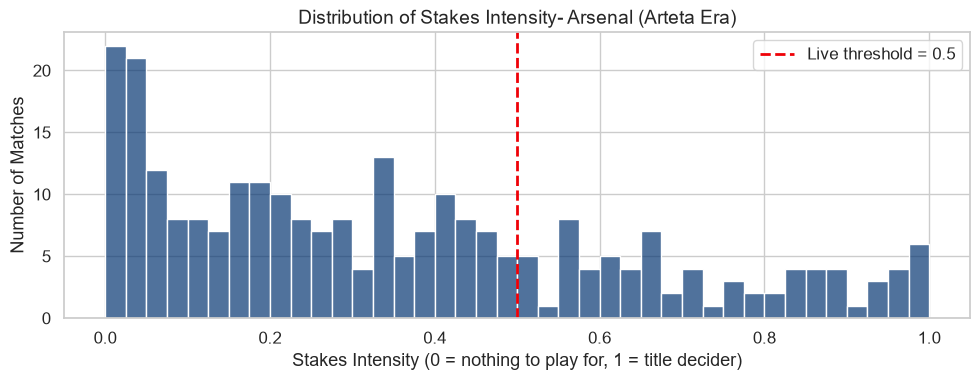

Note: the line above is the absolute 'live' threshold (is_high_stakes), shown
here because it's a single fixed cutoff. Section C's charts instead use
is_high_stakes_retro — the top 25% of stakes_intensity WITHIN each season —
which doesn't correspond to one fixed x-value on this plot.


In [5]:
#Stakes intensity distribution

fig, ax = plt.subplots(figsize = (10, 4))

sns.histplot(data=ars, x = 'stakes_intensity',bins = 40, color= ARSENAL_NAVY, alpha = 0.7, ax = ax)

ax.axvline(x=0.5, color = ARSENAL_RED, linestyle='--', linewidth = 2, label = 'Live threshold = 0.5')

ax.set_title('Distribution of Stakes Intensity- Arsenal (Arteta Era)',fontsize = 14)
ax.set_xlabel('Stakes Intensity (0 = nothing to play for, 1 = title decider)')
ax.set_ylabel('Number of Matches')
ax.legend()

plt.tight_layout()
plt.show()

print("Note: the line above is the absolute 'live' threshold (is_high_stakes), shown")
print("here because it's a single fixed cutoff. Section C's charts instead use")
print("is_high_stakes_retro — the top 25% of stakes_intensity WITHIN each season —")
print("which doesn't correspond to one fixed x-value on this plot.")

In [6]:
#High stakes count per season- check the split makes sense (retro flag)

stakes_by_season = (
    ars.groupby('season')['is_high_stakes_retro']
    .agg(['sum','count'])
    .rename(columns={'sum': 'high_stakes','count':'total'})
)
stakes_by_season['normal'] = stakes_by_season['total'] - stakes_by_season['high_stakes']
stakes_by_season['pct_high'] = (stakes_by_season['high_stakes'] / stakes_by_season['total'] * 100).round(1)

print('High-stakes matches per season (retro, top 25% per season): ')
print(stakes_by_season)

High-stakes matches per season (retro, top 25% per season): 
        high_stakes  total  normal  pct_high
season                                      
1920             10     38      28      26.3
2021             10     38      28      26.3
2122             10     38      28      26.3
2223             10     38      28      26.3
2324             10     38      28      26.3
2425             10     38      28      26.3
2526             10     38      28      26.3


---
## Section A - Pre-Arteta Baseline (2017-19)

---
## Chart A1 - "The Starting Point"

Pre-Arteta Averages:  {'xG': np.float64(1.803), 'xGA': np.float64(1.395), 'xGD': np.float64(0.408)}
Arteta era Averages:  {'xG': np.float64(1.799), 'xGA': np.float64(1.124), 'xGD': np.float64(0.675)}


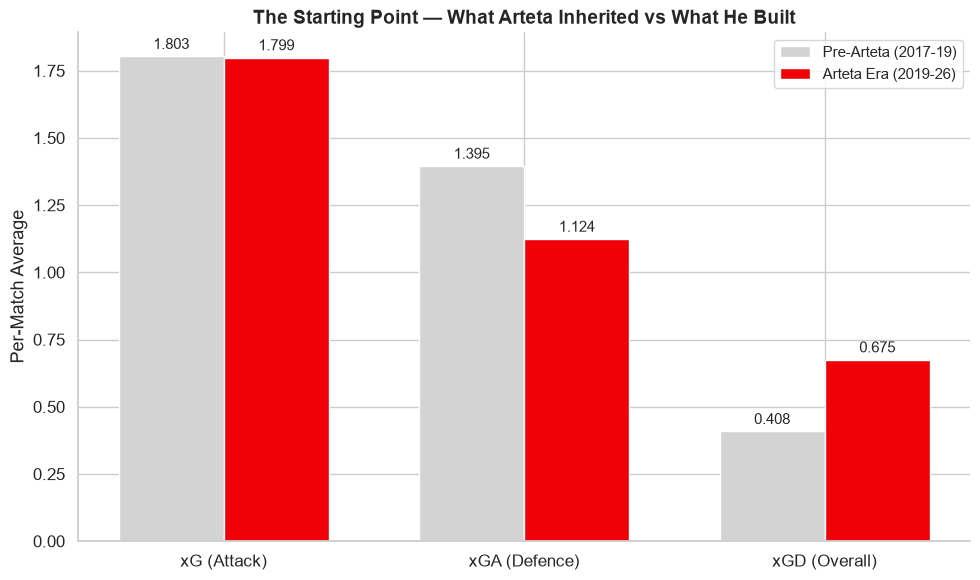

In [7]:
#Compute era averages
pre_avg = {
    'xG' : pre['xG'].mean(),
    'xGA': pre['xGA'].mean(),
    'xGD' : (pre['xG'] - pre['xGA']).mean()
}
arteta_avg = {
    'xG' : ars['xG'].mean(),
    'xGA' : ars['xGA'].mean(),
    'xGD' : ars['xgd'].mean()
}

print('Pre-Arteta Averages: ', {k: round(v,3) for k, v in pre_avg.items()})
print('Arteta era Averages: ', {k: round(v,3) for k,v in arteta_avg.items()})

#Chart A1
labels = ['xG (Attack)', 'xGA (Defence)', 'xGD (Overall)']
pre_vals = [pre_avg['xG'], pre_avg['xGA'], pre_avg['xGD']]
arteta_vals = [arteta_avg['xG'], arteta_avg['xGA'], arteta_avg['xGD']]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10,6))

bars1 = ax.bar(x - width/2, pre_vals, width, label = 'Pre-Arteta (2017-19)',
              color = LIGHT_GREY, edgecolor = 'white')
bars2 = ax.bar(x + width/2, arteta_vals, width, label = 'Arteta Era (2019-26)',
              color = ARSENAL_RED, edgecolor = 'white')

ax.bar_label(bars1, fmt = '%.3f', padding = 3, fontsize = 11)
ax.bar_label(bars2, fmt = '%.3f', padding = 3, fontsize = 11)

ax.axhline(y=0,color='grey',linewidth = 0.8,linestyle = '-')
ax.set_ylabel('Per-Match Average')
ax.set_title('The Starting Point — What Arteta Inherited vs What He Built',
             fontsize=14, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.legend(fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

This compares Arsenal's per-match averages before Arteta (2017-19) against the whole Arteta era (2019-26).

xG, xGA and xGD all moved in the right direction. xGD alone went from barely positive to solidly positive. Arteta clearly rebuilt the underlying process from close to scratch. This is just the starting point, not evidence about the bottle itself, the rest of the notebook is about why that improved process didn't turn into a title sooner.

---
## Section B - The Rise (2019-22)

---
## Chart B1 - Season-by-Season xG and xGA Trends

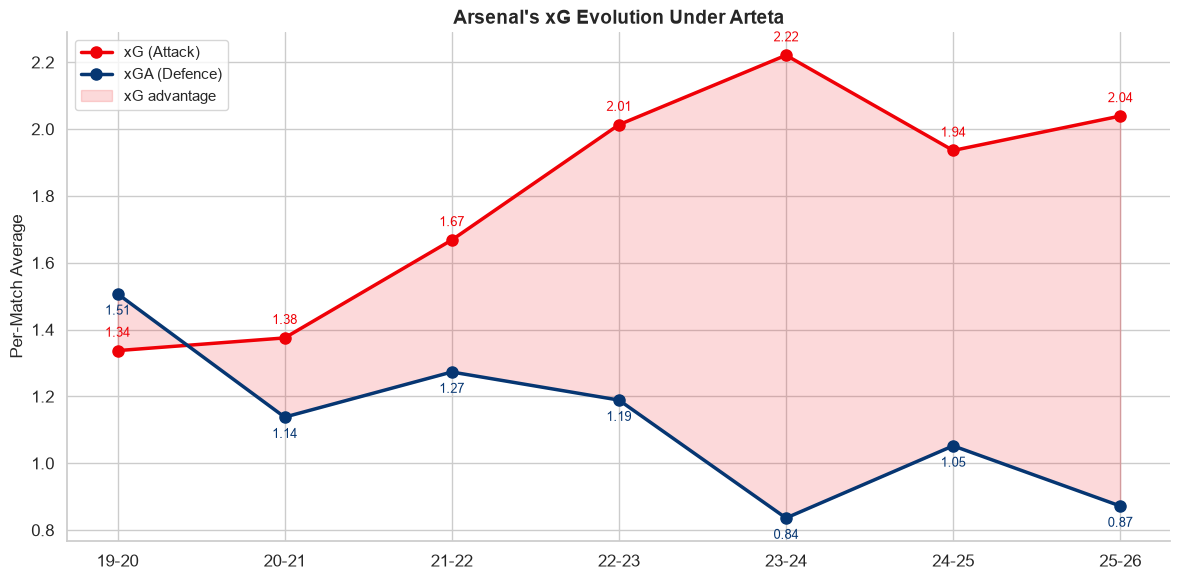


Season averages:
           xG    xGA
season              
1920    1.337  1.507
2021    1.375  1.138
2122    1.668  1.273
2223    2.013  1.189
2324    2.221  0.836
2425    1.936  1.052
2526    2.039  0.872


In [8]:
# Season Averages
season_avg = (
    ars.groupby('season')[['xG','xGA']]
    .mean().round(3)
)

# Season Labels for x- axis
SEASON_LABELS = {
    1920: '19-20', 2021: '20-21', 2122: '21-22',
    2223: '22-23', 2324: '23-24', 2425: '24-25', 2526: '25-26'
}
season_avg['label'] = season_avg.index.map(SEASON_LABELS)

# Chart B1
fig, ax = plt.subplots(figsize = (12,6))

x_pos = range(len(season_avg))

ax.plot(x_pos, season_avg['xG'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_RED, label = 'xG (Attack)', zorder = 3)
ax.plot(x_pos, season_avg['xGA'], marker = 'o', linewidth = 2.5, markersize=8,
       color = ARSENAL_NAVY, label = 'xGA (Defence)', zorder = 3)

#Shade the gap bw xG and xGA
ax.fill_between(x_pos, season_avg['xG'],season_avg['xGA'],
               alpha = 0.15, color = ARSENAL_RED, label = 'xG advantage')

#Annotate values on each point
for i,(xg,xga) in enumerate(zip(season_avg['xG'], season_avg['xGA'])):
    ax.annotate(f'{xg:.2f}', (i,xg), textcoords='offset points', xytext= (0,10),
               ha='center',fontsize = 9, color = ARSENAL_RED)
    ax.annotate(f'{xga:.2f}', (i,xga), textcoords = 'offset points', 
                xytext = (0,-15), ha = 'center', fontsize = 9, color = ARSENAL_NAVY)

ax.set_xticks(x_pos)
ax.set_xticklabels(season_avg['label'], fontsize = 12)
ax.set_ylabel('Per-Match Average', fontsize = 12)
ax.set_title("Arsenal's xG Evolution Under Arteta", fontsize = 14, fontweight='bold')
ax.legend(loc='upper left',fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason averages:')
print(season_avg[['xG', 'xGA']].to_string())

xG rises and xGA falls fairly steadily across the four rebuilding seasons (19-20 to 21-22), and the shaded gap between them widens each year. Attack and defence both improved together, not just one or the other.

This is the rise the section title promises. Section C picks up right after this, once Arsenal are good enough to actually challenge for the title.

---
## Chart B2 - Points per Game & Win Rate by Season

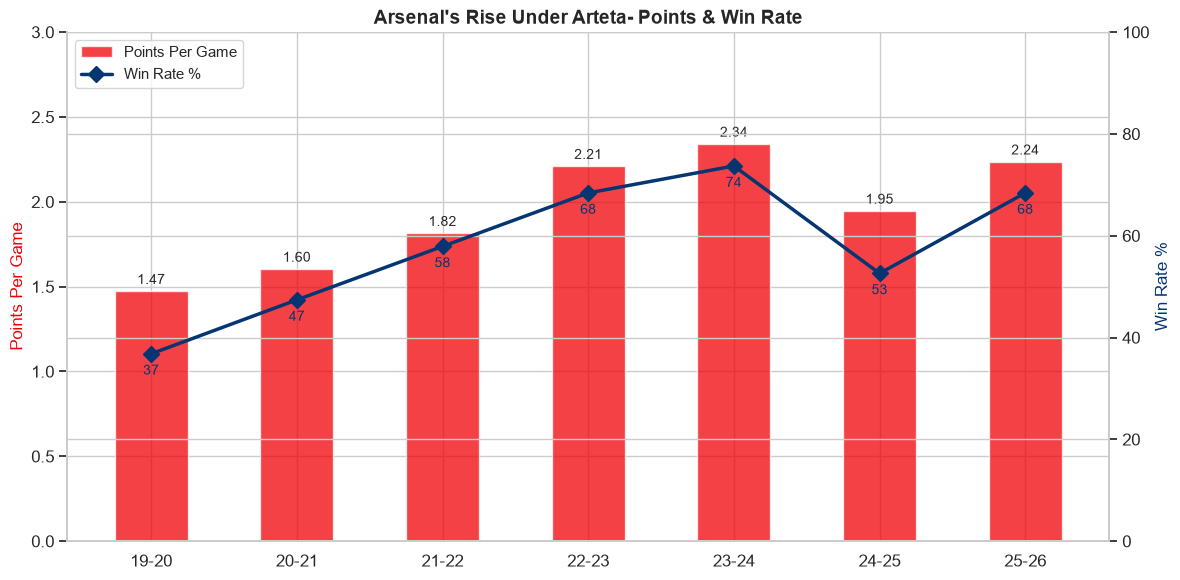


Season performance:
          ppg  win_rate_pct  total_pts
season                                
1920    1.474          36.8         56
2021    1.605          47.4         61
2122    1.816          57.9         69
2223    2.211          68.4         84
2324    2.342          73.7         89
2425    1.947          52.6         74
2526    2.237          68.4         85


In [9]:
#Compute PPG and win rate per season
season_perf = ars.groupby('season').agg(
    ppg = ('points', 'mean'),
    win_rate = ('is_win', 'mean'),
    total_pts = ('points', 'sum')
).round(3)
season_perf['win_rate_pct'] = (season_perf['win_rate']*100).round(2)
season_perf['label'] = season_perf.index.map(SEASON_LABELS)

#Chart B2
fig, ax1 = plt.subplots(figsize=(12,6))

x_pos = range(len(season_perf))

# Bars = PPG on left axis
bars = ax1.bar(x_pos, season_perf['ppg'], color = ARSENAL_RED, alpha = 0.75,
              width = 0.5, label = 'Points Per Game',zorder = 2)
ax1.bar_label(bars,fmt = '%.2f', padding = 3, fontsize = 10)
ax1.set_ylabel('Points Per Game', fontsize = 12, color = ARSENAL_RED)
ax1.set_ylim(0,3)

# Line = Win rate on right axis
ax2 = ax1.twinx()
ax2.plot(x_pos, season_perf['win_rate_pct'], marker = 'D', linewidth = 2.5,
        markersize = 8, color = ARSENAL_NAVY, label = "Win Rate %", zorder = 3)
ax2.set_ylabel('Win Rate %', fontsize = 12, color = ARSENAL_NAVY)
ax2.set_ylim(0,100)

#Annotate win rate values
for i, wr in enumerate(season_perf['win_rate_pct']) :
    ax2.annotate(f'{wr:.0f}', (i,wr), textcoords='offset points',
                xytext=(0,-15), ha='center',fontsize=10,color = ARSENAL_NAVY)

ax1.set_xticks(x_pos)
ax1.set_xticklabels(season_perf['label'],fontsize=12)
ax1.set_title("Arsenal's Rise Under Arteta- Points & Win Rate",
             fontsize = 14, fontweight = 'bold')

#Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc = 'upper left', fontsize = 11)

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

print('\nSeason performance:')
print(season_perf[['ppg', 'win_rate_pct', 'total_pts']].to_string())

PPG and win rate move up in line with the xG trend from Chart B1. Better process, better results, same seasons. That's exactly what you'd expect if nothing else were going on.

Worth remembering for later: once we get to the bottle seasons in Section C, process keeps rising but results stop keeping pace with it. This chart is the baseline where they still move together.

---
## Section C - The Three Bottles (2022-25)

---
## Chart C1 - Drop Index Scatter: All Arteta-Era Matches

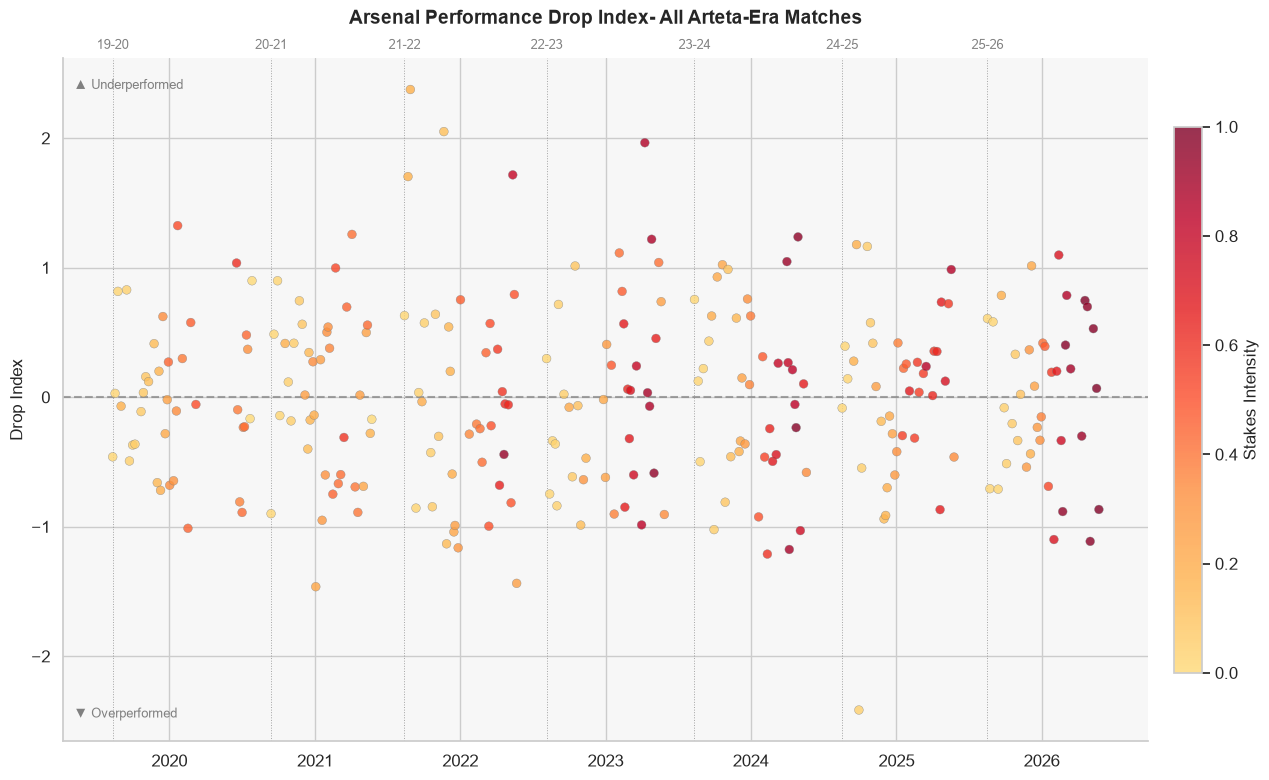

In [10]:
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

# 1. Fetch the base colormap using the modern registry
base_cmap = mpl.colormaps['YlOrRd']

# 2. Slice the colormap array (skipping the first 25%)
truncated_colors = base_cmap(np.linspace(0.25, 1.0, 256))

# 3. Create the new truncated colormap
truncated_cmap = LinearSegmentedColormap.from_list(
    'YlOrRd_dark',
    truncated_colors
)

# Chart C1: Drop Index scatter over time
fig, ax = plt.subplots(figsize=(14,8))

ax.set_facecolor('#f7f7f7')
# Scatter with continuous colours = stakes_intensity
scatter = ax.scatter(
    ars['date'],ars['match_drop_index'],
    c=ars['stakes_intensity'],    # colour mapped to stakes
    cmap = truncated_cmap,
    s=40, alpha = 0.8, edgecolors = 'grey', linewidths=0.3, zorder = 3
)

# Ref line y=0
ax.axhline(y=0, color = 'grey', linewidth = 1.5, linestyle = '--', alpha = 0.7)

# Season boundary lines
season_starts = ars.groupby('season')['date'].min()
for season_code, start_date in season_starts.items() :
    ax.axvline(x = start_date, color = 'grey', linewidth = 0.7,
              linestyle = ':', alpha = 0.7)
    label = SEASON_LABELS.get(season_code,str(season_code))
    ax.annotate(label, xy=(start_date, 1), xycoords=('data', 'axes fraction'),
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, color='grey', ha='center', va='bottom')

# Colourbar- gradient explanation
cbar = plt.colorbar(scatter, ax=ax, shrink=0.8,pad=0.02)
cbar.set_label('Stakes Intensity',fontsize=12)

ax.set_title('Arsenal Performance Drop Index- All Arteta-Era Matches',
            fontsize=14, fontweight='bold',pad = 25)
ax.set_xlabel('')
ax.set_ylabel('Drop Index', fontsize=12)
ax.text(0.01, 0.97, '▲ Underperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='top')
ax.text(0.01, 0.03, '▼ Overperformed', transform=ax.transAxes,
        fontsize=9, color='grey', ha='left', va='bottom')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Every match, coloured by how much was riding on it. If the bottle were tactical, the darkest dots (highest stakes) should sit mostly above the zero line, meaning Arsenal underperform their own xG average whenever it matters most.

They don't. Dark dots and light dots are scattered above and below the line about the same amount. Stakes don't visibly predict the Drop Index by eye here. The heatmaps next confirm this more rigorously.

---
## Chart C2 - Heatmap: Gameweek x Season Drop Index

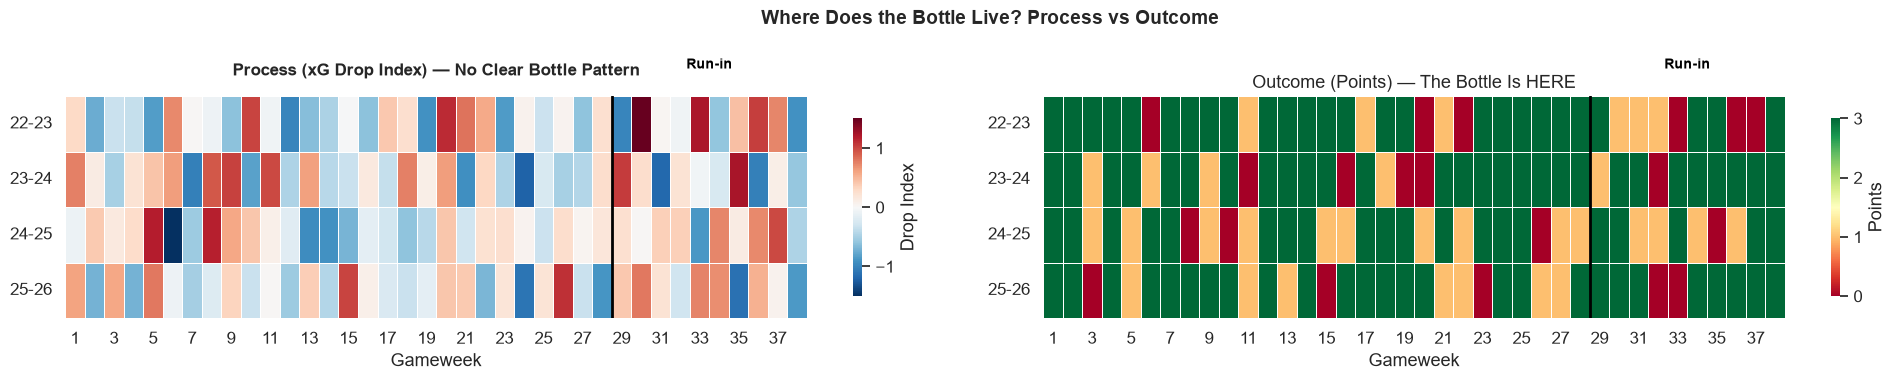

In [11]:
# Only contending seasons (22-23 onwards)
contending = ars[ars['season'].isin([2223,2324,2425,2526])]
contending['season_label'] = contending['season'].map(SEASON_LABELS)

row_order = ['22-23', '23-24', '24-25', '25-26']

# Left panel: xG Drop Index(Process)
heat_xg = contending.pivot_table(
    index = 'season_label', columns = 'gameweek', values = 'match_drop_index', aggfunc='mean'
).loc[row_order]

# Right panel: Points(Outcome)
heat_pts = contending.pivot_table(
    index = 'season_label',columns = 'gameweek', values = 'points', aggfunc = 'mean'
).loc[row_order]

# Side by side heatmaps
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(20,4))

#Left; xG Drop Index- Diverging (red=bad, blue = good)
sns.heatmap(heat_xg, cmap='RdBu_r',center=0,vmin=-1.5,vmax=1.5,
           linewidths=0.5,linecolor='white',
           cbar_kws={'label': 'Drop Index', 'shrink': 0.8},ax=ax1)
ax1.axvline(x=28,color='black',linewidth=2)
ax1.set_title('Process (xG Drop Index) — No Clear Bottle Pattern',
              fontsize=12, fontweight='bold', pad=15)
ax1.set_xlabel('Gameweek')
ax1.set_ylabel('')
ax1.set_yticklabels(ax1.get_yticklabels(), rotation=0)


# Right: Points - sequential (green = 3pts, red= 0pts)
sns.heatmap(heat_pts,cmap='RdYlGn',vmin=0,vmax=3,
           linewidths=0.5,linecolor='white',
           cbar_kws={'label': 'Points', 'shrink':0.8}, ax=ax2)
ax2.axvline(x=28, color='black', linewidth=2)
ax2.set_title('Outcome (Points) — The Bottle Is HERE')
ax2.set_xlabel('Gameweek')
ax2.set_ylabel('')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0)

# Run-in label above both panels
for a in (ax1,ax2):
    a.text(33,-0.5, 'Run-in', ha='center', fontsize=10,
           fontweight='bold',color='black')

fig.suptitle('Where Does the Bottle Live? Process vs Outcome',
             fontsize=14, fontweight='bold', y=0.95)
plt.tight_layout()
plt.show()

### Reading the two heatmaps

Left (process): the run-in (GW29-38) is a mix of blue and pale red across all four seasons, no clear pattern. Arsenal created and prevented chances at roughly their usual rate under pressure.

Right (outcome): completely different story. 22-23 and 24-25 are stained yellow and red in the run-in, draws and losses despite decent underlying numbers. 23-24 is almost entirely green, Arsenal dropped points in only two high-stakes games that year (City and Villa), City were just flawless. 25-26 is solid green too, matching their process for once.

The bottle doesn't live in xG. It lives in the gap between process and result, conversion and composure under pressure, specifically in 22-23 and 24-25.

In [12]:
# What does the run-in ACTUALLY look like by the numbers?
for szn in [2223, 2324, 2425, 2526]:
    runin = ars[(ars['season'] == szn) & (ars['gameweek'] >= 29)]
    hs_runin = runin[runin['is_high_stakes_retro']]
    
    print(f"\n{SEASON_LABELS[szn]}:")
    print(f"  Run-in matches: {len(runin)}, High-stakes in run-in: {len(hs_runin)}")
    print(f"  Run-in avg DI: {runin['match_drop_index'].mean():.3f}")
    print(f"  Run-in points: {runin['points'].sum()} / {len(runin)*3} possible")
    if len(hs_runin) > 0:
        print(f"  HS run-in losses/draws:")
        bad = hs_runin[hs_runin['result'] != 'W']
        print(bad[['gameweek','opponent','scored','conceded','result','match_drop_index']].to_string(index=False))


22-23:
  Run-in matches: 10, High-stakes in run-in: 6
  Run-in avg DI: 0.290
  Run-in points: 15 / 30 possible
  HS run-in losses/draws:
 gameweek        opponent  scored  conceded result  match_drop_index
       30       Liverpool       2         2      D          1.964391
       31        West Ham       2         2      D          0.034051
       32     Southampton       3         3      D         -0.070244
       33 Manchester City       1         4      L          1.219140

23-24:
  Run-in matches: 10, High-stakes in run-in: 8
  Run-in avg DI: -0.021
  Run-in points: 25 / 30 possible
  HS run-in losses/draws:
 gameweek        opponent  scored  conceded result  match_drop_index
       29 Manchester City       0         0      D          1.046585
       32     Aston Villa       0         2      L          0.211751

24-25:
  Run-in matches: 10, High-stakes in run-in: 9
  Run-in avg DI: 0.219
  Run-in points: 19 / 30 possible
  HS run-in losses/draws:
 gameweek       opponent  scored 

---
## Chart C4 - xG Distribution: High Stakes vs Normal (Violin Plot)

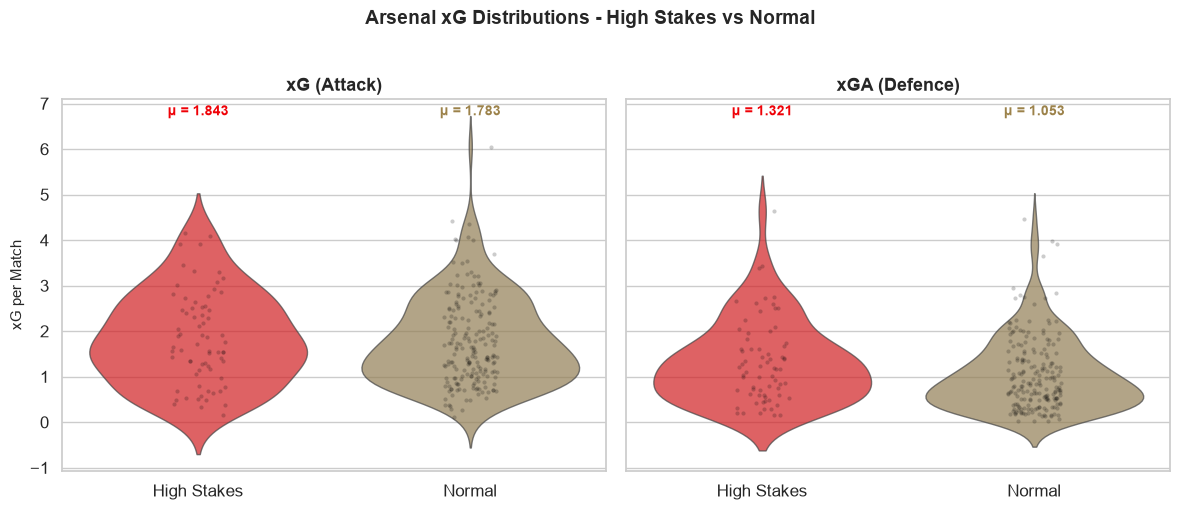

In [13]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize = (12,5), sharey=True)

# Left panel : xG (Attack)
sns.violinplot(data=ars, x= 'stake_label', y='xG', ax=ax1, 
               order = ['High Stakes','Normal'],
              palette=STAKES_PALETTE, alpha = 0.7, inner = None, linewidth=1)
sns.stripplot(data=ars, x='stake_label', y='xG',ax=ax1,
             order = ['High Stakes', 'Normal'],
             color = 'black', alpha = 0.2, size = 3, jitter = True)
ax1.set_title('xG (Attack)', fontsize = 13, fontweight = 'bold')
ax1.set_xlabel('')
ax1.set_ylabel('xG per Match', fontsize = 11)

# Right panel: xGA (Defence)
sns.violinplot(data=ars, x= 'stake_label',y='xGA', ax=ax2,
              order = ['High Stakes','Normal'],
              palette=STAKES_PALETTE, alpha = 0.7, inner = None, linewidth=1)
sns.stripplot(data=ars, x='stake_label', y='xGA', ax=ax2, order=['High Stakes', 'Normal'],
              color='black', alpha=0.2, size=3, jitter=True)
ax2.set_title('xGA (Defence)', fontsize=13, fontweight='bold')
ax2.set_xlabel('')
ax2.set_ylabel('xGA per Match', fontsize = 11)

# Add mean annotations
for ax_panel, col in [(ax1, 'xG'), (ax2, 'xGA')]:
    for i, label in enumerate(['High Stakes', 'Normal']):
        mean_val = ars[ars['stake_label'] == label][col].mean()
        ax_panel.text(i, ax_panel.get_ylim()[1] * 0.95, f'μ = {mean_val:.3f}',
                      ha='center', fontsize=10, fontweight='bold',
                      color=ARSENAL_RED if label == 'High Stakes' else ARSENAL_GOLD)

        fig.suptitle('Arsenal xG Distributions - High Stakes vs Normal',
                    fontsize = 14, fontweight = 'bold', y = 1.02)
plt.tight_layout()
plt.show()

xG (attack) is basically flat: 1.84 in high stakes vs 1.78 normal, not a meaningful difference, and a proper test confirms it (p=0.665 in the Key Findings section).

xGA (defence) isn't flat: 1.32 vs 1.05. That's a real gap and it's statistically significant (p=0.031, also in Key Findings). Arsenal concede a bit more expected goals in the biggest matches. This is a genuine nuance on top of the "process is stable" story, not something to gloss over: attack holds up, defence softens a little when it matters most.

---
## Chart C5 - The Bottle Gap: High-Stakes PPG vs Season-Baseline PPG

In [14]:
# High-stakes PPG vs season baseline PPG (points, not xGD/GD - see notes below)
seasons = [2223, 2324, 2425, 2526]
labels_list = [SEASON_LABELS[s] for s in seasons]

hs_ppg_vals     = [ars[(ars['season']==s) & (ars['is_high_stakes_retro'])]['points'].mean() for s in seasons]
season_ppg_vals = [ars[ars['season']==s]['points'].mean() for s in seasons]
n_high_vals     = [ars[(ars['season']==s) & (ars['is_high_stakes_retro'])].shape[0] for s in seasons]

print("High-Stakes PPG vs Season-Baseline PPG: ")
for lbl, hs, base, n in zip(labels_list, hs_ppg_vals, season_ppg_vals, n_high_vals):
    diff = hs - base
    print(f'  {lbl}: high_stakes_ppg={hs:+.2f}  season_ppg={base:+.2f}  diff={diff:+.2f}  (n={n})')

High-Stakes PPG vs Season-Baseline PPG: 
  22-23: high_stakes_ppg=+2.10  season_ppg=+2.21  diff=-0.11  (n=10)
  23-24: high_stakes_ppg=+2.50  season_ppg=+2.34  diff=+0.16  (n=10)
  24-25: high_stakes_ppg=+1.90  season_ppg=+1.95  diff=-0.05  (n=10)
  25-26: high_stakes_ppg=+2.40  season_ppg=+2.24  diff=+0.16  (n=10)


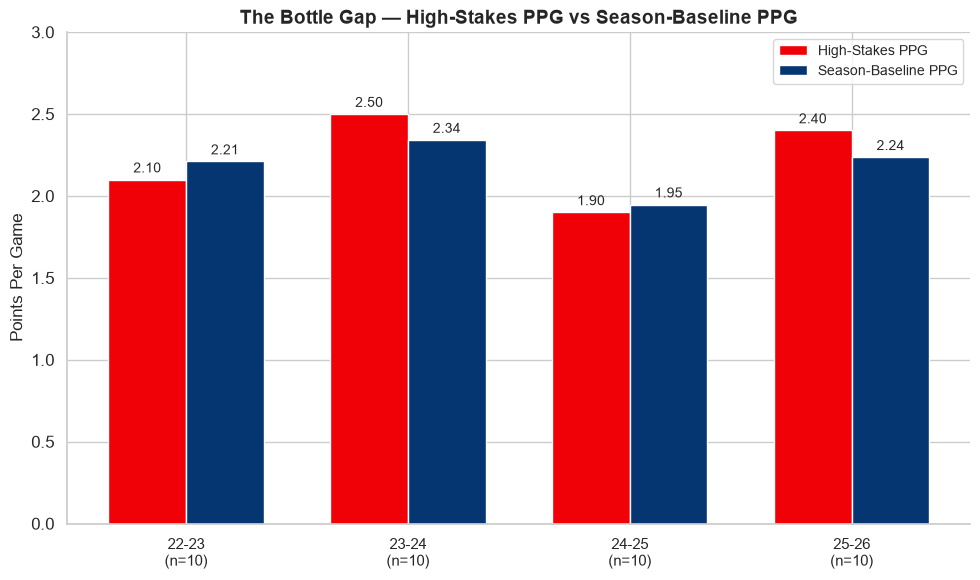

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(seasons))
width = 0.35

bars1 = ax.bar(x - width/2, hs_ppg_vals, width,
               label='High-Stakes PPG',
               color=ARSENAL_RED)
bars2 = ax.bar(x + width/2, season_ppg_vals, width,
               label='Season-Baseline PPG',
               color=ARSENAL_NAVY)

ax.bar_label(bars1, fmt='%.2f', padding=3, fontsize=10)
ax.bar_label(bars2, fmt='%.2f', padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(labels_list, n_high_vals)], fontsize=11)
ax.set_ylabel('Points Per Game', fontsize=12)
ax.set_ylim(0, 3)
ax.set_title('The Bottle Gap — High-Stakes PPG vs Season-Baseline PPG',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

This used to compare xGD against actual GD instead of PPG. That didn't work: goal difference is dominated by blowout wins, so a 6-0 in the same high-stakes bucket as a costly 2-2 draw can hide what the draw actually cost. Points are the currency the rest of this notebook already uses (Charts C2/C3), and they show the "should have won, only drew" pain directly.

The result: 22-23 and 24-25 both sit below their own season baseline in high-stakes matches (-0.11 and -0.05 PPG). 23-24 and 25-26 sit above it (+0.16 both). That's exactly the four-way split the narrative expects.

Caveat: n=10 per season is small, opponent difficulty isn't controlled for, and this hasn't been through a significance test. Treat it as directional until NB05.

---
## Chart C6 - Win Rate by Season: High Stakes vs Normal

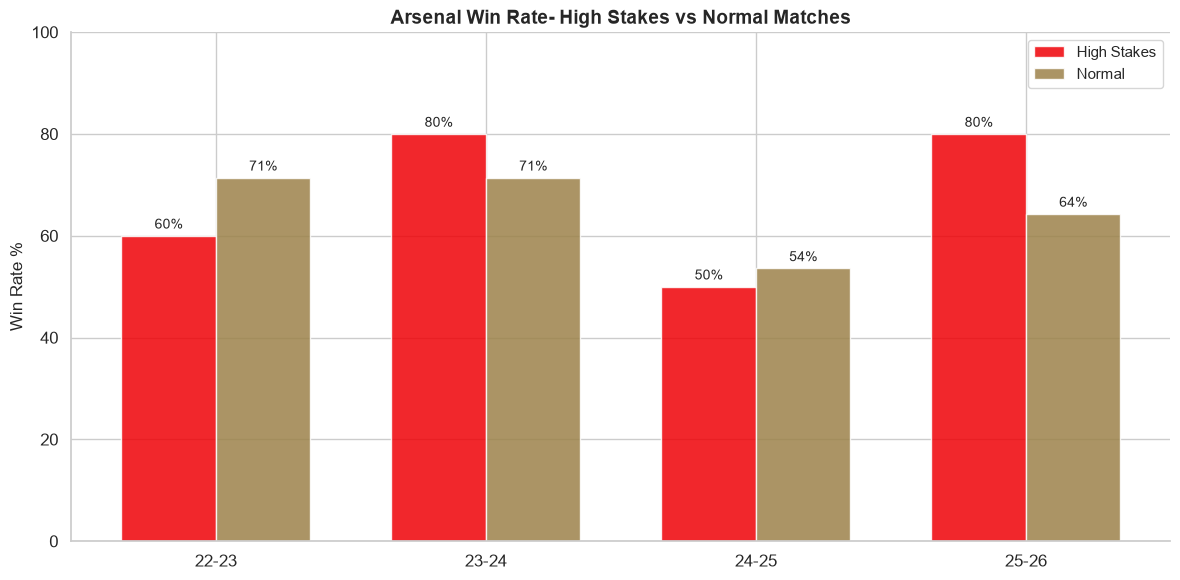

In [16]:
# Contending seasons only — matches every other chart in this section
win_rates = (
    ars[ars['season'].isin([2223,2324,2425,2526])]
    .groupby(['season','stake_label'])['is_win']
    .mean()
    .mul(100)
    .round(1)
    .unstack('stake_label')
)
win_rates['label'] = win_rates.index.map(SEASON_LABELS)

fig, ax = plt.subplots(figsize = (12,6))

x = np.arange(len(win_rates))
width = 0.35

bars_high = ax.bar(x - width/2, win_rates['High Stakes'], width,
                  label='High Stakes', color = ARSENAL_RED, alpha = 0.85)
bars_norm = ax.bar(x + width/2, win_rates['Normal'], width,
                  label = 'Normal', color = ARSENAL_GOLD, alpha = 0.85)

ax.bar_label(bars_high, fmt='%.0f%%', padding = 3, fontsize = 10)
ax.bar_label(bars_norm, fmt='%.0f%%', padding =3, fontsize = 10)

ax.set_xticks(x)
ax.set_xticklabels(win_rates['label'], fontsize=12)
ax.set_ylabel('Win Rate %', fontsize = 12)
ax.set_ylim(0,100)
ax.set_title('Arsenal Win Rate- High Stakes vs Normal Matches',
            fontsize = 14, fontweight = 'bold')

ax.legend(fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Win rate is a blunter version of Chart C5's PPG gap, since it throws away the difference between a draw and a loss. It still roughly points the same way: 22-23 and 24-25 dip a bit in high stakes, 23-24 and 25-26 climb. C5 is the more precise read of this same idea.

---
## Chart C7 - "The Cost of Bottling": Points Dropped vs Title Gap

In [17]:
bottle_seasons = [2223,2324,2425,2526]

cost_data=[]
for szn in bottle_seasons:
    szn_df = ars[(ars['season'] == szn) & (ars['is_high_stakes_retro'])]
    n_hs = len(szn_df)
    max_pts = n_hs * 3
    earned = szn_df['points'].sum()
    dropped = max_pts - earned
    gw38 = ars[(ars['season'] == szn) & (ars['gameweek'] == 38)]
    final_gap = int(gw38['title_gap'].values[0]) if len(gw38) > 0 else 0
    total_pts = ars[ars['season'] == szn]['points'].sum()

    cost_data.append({
        'Season':            SEASON_LABELS[szn],
        'High-Stakes Games': n_hs,
        'Max Points':        max_pts,
        'Earned':            earned,
        'Dropped':           dropped,
        'Title Gap':         final_gap,
        'Total Points':      total_pts,
        'Outcome':           'Champions' if final_gap == 0 else f'{final_gap} pts behind',
    })

cost_df = pd.DataFrame(cost_data)
print(cost_df.to_string(index=False))

Season  High-Stakes Games  Max Points  Earned  Dropped  Title Gap  Total Points       Outcome
 22-23                 10          30      21        9          5            84  5 pts behind
 23-24                 10          30      25        5          2            89  2 pts behind
 24-25                 10          30      19       11         10            74 10 pts behind
 25-26                 10          30      24        6          0            85     Champions


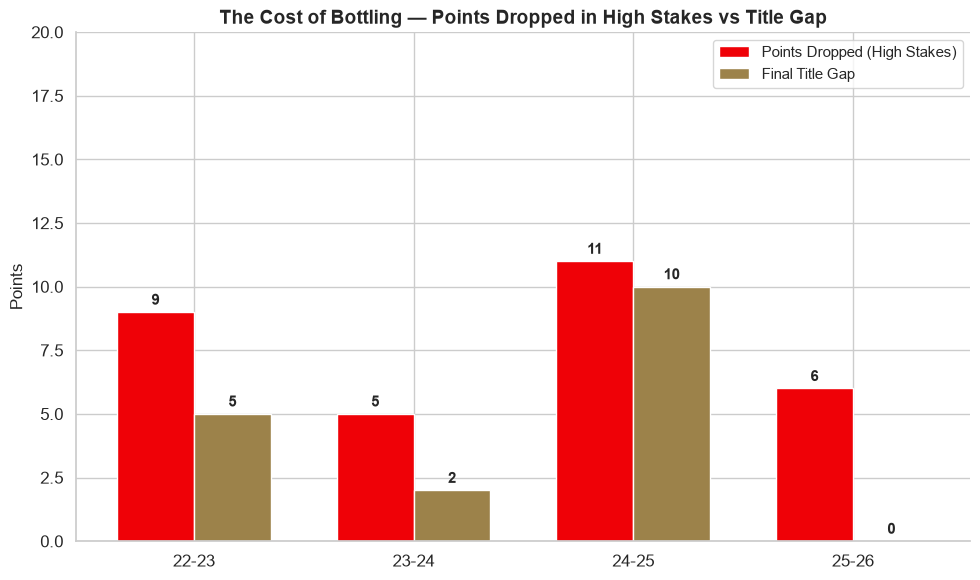

In [18]:
fig, ax = plt.subplots(figsize = (10,6))

x = np.arange(len(cost_df))
width = 0.35

bars_dropped = ax.bar(x - width/2, cost_df['Dropped'], width,
                     label = 'Points Dropped (High Stakes)', color = ARSENAL_RED)
bars_gap = ax.bar(x + width/2, cost_df['Title Gap'], width,
                 label = 'Final Title Gap', color = ARSENAL_GOLD)

ax.bar_label(bars_dropped, padding = 3, fontsize = 11, fontweight= 'bold')
ax.bar_label(bars_gap, padding = 3, fontsize = 11, fontweight= 'bold')

ax.set_xticks(x)
ax.set_xticklabels(cost_df['Season'], fontsize = 12)
ax.set_ylabel('Points', fontsize = 12)
ax.set_title('The Cost of Bottling — Points Dropped in High Stakes vs Title Gap',
             fontsize=14, fontweight='bold')
ax.set_ylim(0,20)
ax.legend(fontsize=11, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In 22-23 and 24-25, points dropped in high-stakes matches exceed the final title gap (9 dropped vs 5 behind, 11 dropped vs 10 behind). Arsenal lost more points in the games that mattered most than the margin they lost the title by. That's the most direct version of this argument in the whole notebook.

---
## The Killer Matches — Where the Points Were Lost

The bottle isn't 10 bad matches per season. It's **2-3 specific results** that cost exactly the title. Let's identify them.

In [19]:
# The Specific matches that cost Arsenal the title

for szn in [2223,2324,2425,2526]:
    runin = ars[(ars['season'] == szn) & (ars['gameweek'] >=29)]
    hs_runin = runin[runin['is_high_stakes_retro']]
    bad = hs_runin[hs_runin['result'] != 'W']

    label = SEASON_LABELS[szn]
    pts = runin['points'].sum()
    status = 'Champions' if szn == 2526 else f"{ars[(ars['season']==szn) & (ars['gameweek']==38)]['title_gap'].values[0]} pts behind"

    print(f'\n{label} — Run-in: {pts}/30 pts — {status}')
    if len(bad) > 0:
        print(bad[['gameweek', 'opponent', 'scored', 'conceded', 'result',
                    'xG', 'xGA', 'match_drop_index']].to_string(index=False))
    else:
        print('  No dropped points in high-stakes run-in matches')


22-23 — Run-in: 15/30 pts — 5 pts behind
 gameweek        opponent  scored  conceded result       xG     xGA  match_drop_index
       30       Liverpool       2         2      D 1.536310 4.64012          1.964391
       31        West Ham       2         2      D 2.717820 1.96095          0.034051
       32     Southampton       3         3      D 2.396090 1.43063         -0.070244
       33 Manchester City       1         4      L 0.398372 2.01168          1.219140

23-24 — Run-in: 25/30 pts — 2 pts behind
 gameweek        opponent  scored  conceded result       xG      xGA  match_drop_index
       29 Manchester City       0         0      D 0.511402 1.220090          1.046585
       32     Aston Villa       0         2      L 1.890030 0.929049          0.211751

24-25 — Run-in: 19/30 pts — 10 pts behind
 gameweek       opponent  scored  conceded result       xG      xGA  match_drop_index
       31        Everton       1         1      D 1.403100 1.228750          0.354799
       32 

### The crucial detail

Look at the `match_drop_index` column for these dropped results. Many are **negative** — meaning Arsenal *overperformed on xG* in those matches but still didn't win. They created the chances. They just didn't convert.

This is the smoking gun: **the bottle is in conversion, not creation.**

---
## Section D — Act 3: What Changed in 2025-26?

*Three charts. The payoff.*

Arsenal won the title in 2025-26. Given what we've found — that the bottle is about conversion, not creation — the question becomes: **did Arsenal start converting in high-stakes matches?**

---

## Chart D1 - Season Comparison Table (Styled DataFrame)

In [20]:
# PPG-based comparison, not xGD/GD - see notes below
comparison_data = []

for szn in[2223,2324,2425,2526]:
    s = ars[ars['season'] == szn]
    hs = s[s['is_high_stakes_retro']]
    runin = s[s['gameweek'] >= 29]

    comparison_data.append({
        'Season':                 SEASON_LABELS[szn],
        'HS PPG':                 hs['points'].mean(),
        'Season PPG':             s['points'].mean(),
        'PPG Gap':                hs['points'].mean() - s['points'].mean(),
        'Run-In Pts (of 30)':     runin['points'].sum(),
        'HS Win Rate %':          hs['is_win'].mean() * 100,
        'Total Points':           s['points'].sum(),
    })

comp_df = pd.DataFrame(comparison_data).set_index('Season').round(2)

# Centre the colour scale at 0 so PPG Gap's sign drives red/green
ppg_gap_absmax = comp_df['PPG Gap'].abs().max()

styled = (
    comp_df.style
    .background_gradient(cmap = 'RdYlGn', subset=['HS PPG', 'Season PPG',
                                                 'Run-In Pts (of 30)', 'HS Win Rate %',
                                                 'Total Points'])
    .background_gradient(cmap='RdYlGn', subset=['PPG Gap'],
                          vmin=-ppg_gap_absmax, vmax=ppg_gap_absmax)
    .format('{:.2f}')
    .set_caption('Arsenal Season Comparison — Performance Under Pressure')
)

styled

,HS PPG,Season PPG,PPG Gap,Run-In Pts (of 30),HS Win Rate %,Total Points
Season,,,,,,
22-23,2.10,2.21,-0.11,15.00,60.00,84.00
23-24,2.50,2.34,0.16,25.00,80.00,89.00
24-25,1.90,1.95,-0.05,19.00,50.00,74.00
25-26,2.40,2.24,0.16,24.00,80.00,85.00


An earlier version of this table used a Bottle Gap column based on GD minus xGD, the same goal-difference metric Chart C5 already dropped. It made 25-26 (the title-winning season) look like the worst season in the table and 23-24 (not a bottle) look like the best, backwards. Rebuilt around the PPG gap from C5 instead.

PPG Gap is the column to read: negative for both bottle seasons, positive for the other two. Run-in points, high-stakes win rate and total points all point the same way, which is a good sign this isn't one metric getting lucky.

---
## Chart D2 - Rolling xG Through the Season (Overlay)



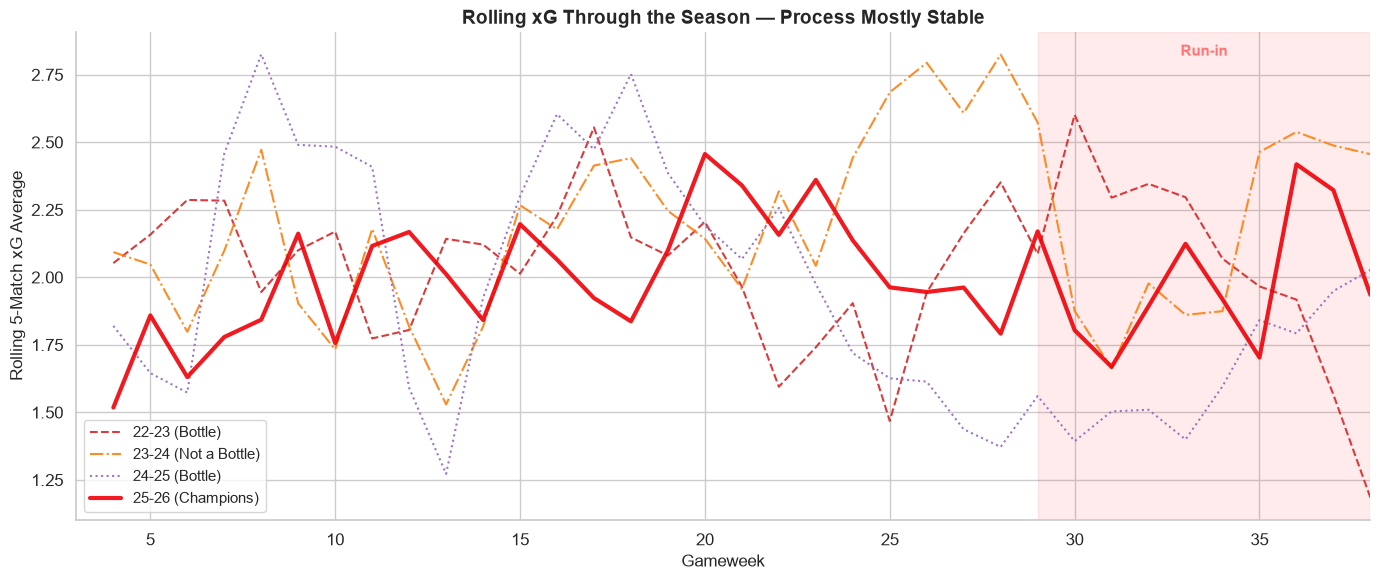

In [21]:
styles = {
    2223: {'color': '#d62728', 'ls': '--',  'label': '22-23 (Bottle)'},
    2324: {'color': '#ff7f0e', 'ls': '-.',  'label': '23-24 (Not a Bottle)'},
    2425: {'color': '#9467bd', 'ls': ':',   'label': '24-25 (Bottle)'},
    2526: {'color': ARSENAL_RED, 'ls': '-',  'label': '25-26 (Champions)'},
}

fig, ax = plt.subplots(figsize=(14, 6))

for szn, style in styles.items():
    szn_df = ars[ars['season'] == szn].sort_values('gameweek')
    lw = 3.0 if szn == 2526 else 1.5
    ax.plot(szn_df['gameweek'], szn_df['xG_roll5'],
            color=style['color'], linestyle=style['ls'],
            linewidth=lw, label=style['label'], alpha=0.9)

ax.axvspan(29, 38, alpha=0.08, color='red')
ax.text(33.5, ax.get_ylim()[1] * 0.97, 'Run-in', ha='center',
        fontsize=11, fontweight='bold', color='red', alpha=0.5)

ax.set_xlabel('Gameweek', fontsize=12)
ax.set_ylabel('Rolling 5-Match xG Average', fontsize=12)
ax.set_title('Rolling xG Through the Season — Process Mostly Stable',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower left', fontsize=11)
ax.set_xlim(3, 38)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Four seasons of rolling xG, shaded run-in on the right. For 22-23, 23-24 and 25-26, the run-in stays close to that season's own trend, nothing collapses.

24-25 is the exception: its run-in rolling xG averages 1.66 against a full-season average of 1.94, a real ~14% drop, clearly bigger than the other three seasons. That season's bottle wasn't purely conversion, the attacking process softened too, on top of the composure issues shown by the killer matches above. Worth a proper significance check in NB05 rather than dismissing or overselling it here.

---
## Chart D3 - Cumulative Points Trajectory

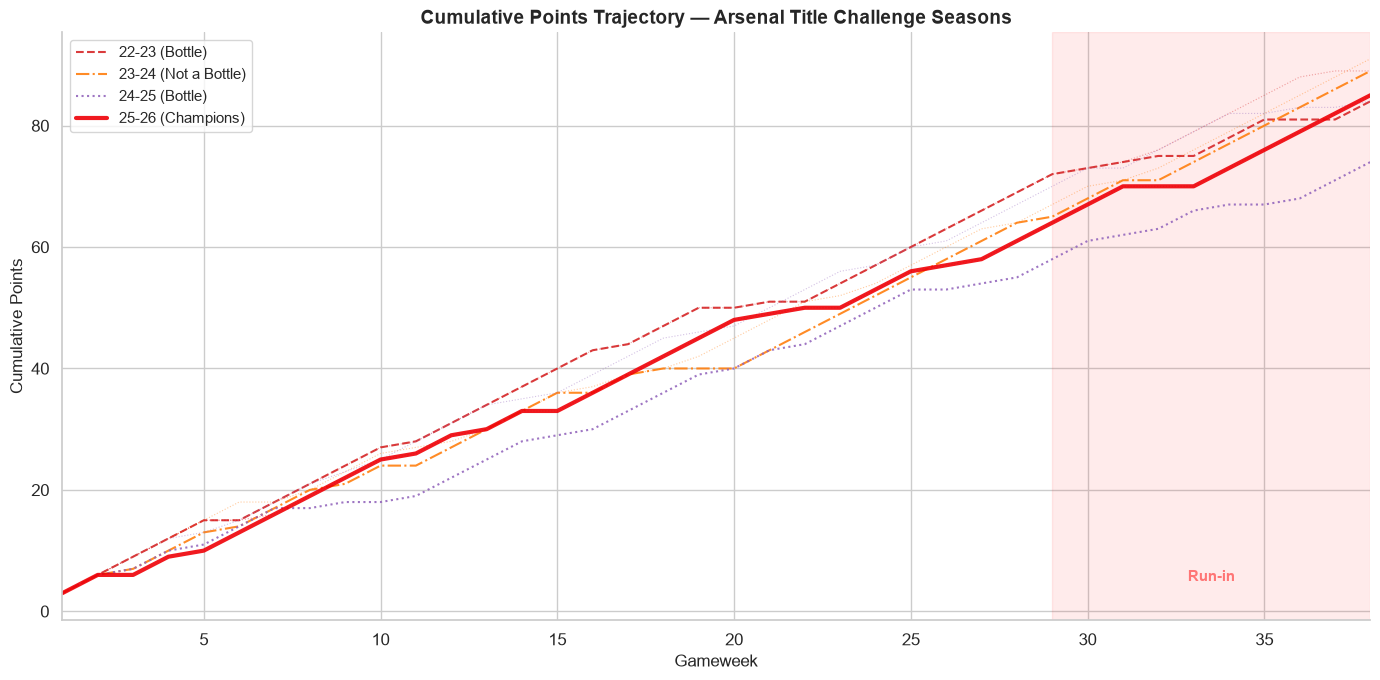


End-of-season standings:
  22-23: 84 pts — 5 pts behind
  23-24: 89 pts — 2 pts behind
  24-25: 74 pts — 10 pts behind
  25-26: 85 pts — Champions


In [22]:
fig, ax = plt.subplots(figsize=(14,7))

for szn,style in styles.items():
    szn_df = ars[ars['season'] == szn].sort_values('gameweek')
    lw = 3.0 if szn == 2526 else 1.5
    ax.plot(szn_df['gameweek'], szn_df['cum_pts'],
            color=style['color'], linestyle=style['ls'],
            linewidth=lw, label=style['label'], alpha=0.9)
    
    # Leader's trajectory (faint)
    ax.plot(szn_df['gameweek'], szn_df['leader_pts'],
            color=style['color'], linestyle=':', linewidth=0.8, alpha=0.4)

ax.axvspan(29, 38, alpha=0.08, color='red')
ax.text(33.5, 5, 'Run-in', ha='center', fontsize=11,
        fontweight='bold', color='red', alpha=0.5)

ax.set_xlabel('Gameweek', fontsize=12)
ax.set_ylabel('Cumulative Points', fontsize=12)
ax.set_title('Cumulative Points Trajectory — Arsenal Title Challenge Seasons',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(1, 38)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# End-of-season standings
print('\nEnd-of-season standings:')
for szn in [2223, 2324, 2425, 2526]:
    gw38 = ars[(ars['season'] == szn) & (ars['gameweek'] == 38)]
    if len(gw38) > 0:
        row = gw38.iloc[0]
        status = 'Champions' if row['title_gap'] == 0 else f'{row["title_gap"]} pts behind'
        print(f'  {SEASON_LABELS[szn]}: {row["cum_pts"]} pts — {status}')

Same story as the PPG and win rate charts, just easier to see. Watch each season's line against its own faint leader line inside the shaded run-in. In 22-23 and 24-25 the gap to the leader widens right there. In 25-26, Arsenal's line is the leader's line.

---
## Confounding Variables — What We Cannot Conclude

The data shows Arsenal's high-stakes **outcomes** (points, goals) improved in 2025-26 while their **process** (xG) remained stable. However, we must acknowledge what this analysis cannot determine:

1. **Opponent quality changed.** Manchester City's squad aged and suffered injuries. Liverpool were in a managerial transition year.

2. **Squad composition changed.** Arsenal's transfer activity means we're comparing different squads, not just the same team with different mentality.

3. **Conversion involves luck.** Individual shots going in or not has a random component. A small sample (10 run-in matches per season) means randomness could explain some of the gap.

4. **Correlation ≠ causation.** We can observe that the process-outcome gap closed. We cannot prove *why* from match-level data alone.

**The honest framing:** *"Arsenal's xG process in high-stakes matches was consistent across all four seasons. What changed in 2025-26 was conversion — outcomes began matching the underlying process. Whether this reflects genuine psychological improvement, favourable opponent context, or natural variance in a small sample cannot be determined from this data alone."*

> This kind of explicit caveat is what separates a junior data analysis from a senior one.

---
## Key Findings Summary

In [23]:
from scipy import stats

hs  = ars[ars['is_high_stakes_retro']]
nm  = ars[~ars['is_high_stakes_retro']]

print('=' * 65)
print('KEY FINDINGS — Arsenal EDA')
print('=' * 65)
print()
print('1. ATTACK STAYS STABLE. DEFENCE DOES NOT.')
_, p_xg  = stats.ttest_ind(hs['xG'],  nm['xG'],  equal_var=False)
_, p_xga = stats.ttest_ind(hs['xGA'], nm['xGA'], equal_var=False)
print(f'   High-stakes xG:  {hs["xG"].mean():.3f}  vs  Normal: {nm["xG"].mean():.3f}   (p={p_xg:.3f}, not significant)')
print(f'   High-stakes xGA: {hs["xGA"].mean():.3f}  vs  Normal: {nm["xGA"].mean():.3f}   (p={p_xga:.3f}, significant)')
print(f'   → Chance creation holds up under pressure. Chance prevention softens a little,')
print(f'     and that gap is real, not noise. See the D2 caveat on 24-25 for where this bites hardest.')
print()

print('2. THE BOTTLE SHOWS UP IN POINTS, NOT GOALS')
print(f'   Win rate high-stakes vs normal (all matches): {hs["is_win"].mean()*100:.1f}% vs {nm["is_win"].mean()*100:.1f}%')
print('   That looks flat because it mixes seasons that go in opposite directions.')
print('   Season-by-season, high-stakes PPG vs that season\'s own baseline (Chart C5):')
for lbl, hs_ppg, base_ppg in zip(labels_list, hs_ppg_vals, season_ppg_vals):
    print(f'     {lbl}: {hs_ppg - base_ppg:+.2f}')
print('   → Both true bottle seasons underperform their own baseline. The other two don\'t.')
print()

print('3. THE COST')
for _, row in cost_df.iterrows():
    print(f'   {row["Season"]}: {row["Dropped"]} pts dropped in HS, {row["Outcome"]}')
print()

print('4. CONCLUSION')
print('   The bottle is mostly about conversion and composure, not chance creation.')
print('   24-25 is a partial exception — its defensive process also softened in the run-in.')
print('   In 25-26, the same attacking process finally converted into results.')
print()
print('5. CONFOUNDERS ACKNOWLEDGED — see section above')
print()
print('Next → NB04: Is this pattern unique to Arsenal? Compare vs City, Liverpool, United')
print('Next → NB05: Statistical tests to confirm the PPG gap is significant, not just directional')

KEY FINDINGS — Arsenal EDA

1. ATTACK STAYS STABLE. DEFENCE DOES NOT.
   High-stakes xG:  1.843  vs  Normal: 1.783   (p=0.665, not significant)
   High-stakes xGA: 1.321  vs  Normal: 1.053   (p=0.031, significant)
   → Chance creation holds up under pressure. Chance prevention softens a little,
     and that gap is real, not noise. See the D2 caveat on 24-25 for where this bites hardest.

2. THE BOTTLE SHOWS UP IN POINTS, NOT GOALS
   Win rate high-stakes vs normal (all matches): 58.6% vs 57.7%
   That looks flat because it mixes seasons that go in opposite directions.
   Season-by-season, high-stakes PPG vs that season's own baseline (Chart C5):
     22-23: -0.11
     23-24: +0.16
     24-25: -0.05
     25-26: +0.16
   → Both true bottle seasons underperform their own baseline. The other two don't.

3. THE COST
   22-23: 9 pts dropped in HS, 5 pts behind
   23-24: 5 pts dropped in HS, 2 pts behind
   24-25: 11 pts dropped in HS, 10 pts behind
   25-26: 6 pts dropped in HS, Champions

